# Schema Validation 1 results and analysis

Inspect successful assessments, summarize schema coverage signals, review candidate-field evidence, and calculate API spend from recorded token usage.

Costs use [OpenAI's Standard and Flex processing prices](https://developers.openai.com/api/docs/pricing) for GPT-5.5 with less than 272K context, retrieved August 25, 2026. Only successful calls in the results JSONL are included. Candidate names are shown exactly as proposed and are not consolidated across aliases.

In [1]:
import json
from collections import Counter
from pathlib import Path
from typing import Any

import pandas as pd
from IPython.display import Image, Markdown, display

from data_snapshot.constants import ROOT


## Configuration

In [2]:
RESULTS_PATH = ROOT / "notebooks/schema_validation1/outputs/results.jsonl"
ERRORS_PATH = ROOT / "notebooks/schema_validation1/outputs/errors.jsonl"
SNAPSHOTS_DIR = ROOT / "notebooks/schema_validation1/data/snapshots"

# USD per 1 million tokens, context under 272K.
PRICES_USD_PER_1M = {
    ("gpt-5.5", "default"): {
        "input": 5.00,
        "cached_input": 0.50,
        "output": 30.00,
    },
    ("gpt-5.5", "flex"): {
        "input": 2.50,
        "cached_input": 0.25,
        "output": 15.00,
    },
}


In [3]:
def load_jsonl(path: Path) -> list[dict[str, Any]]:
    """Load JSON objects from a JSONL file.

    Parameters
    ----------
    path : Path
        JSONL file to read.

    Returns
    -------
    list[dict[str, Any]]
        Parsed records, or an empty list when the file does not exist.

    Raises
    ------
    ValueError
        If a non-empty line is not valid JSON.
    """
    if not path.exists():
        return []

    records = []
    with path.open(encoding="utf-8") as file:
        for line_number, line in enumerate(file, start=1):
            if not line.strip():
                continue
            try:
                records.append(json.loads(line))
            except json.JSONDecodeError as exc:
                raise ValueError(
                    f"Invalid JSON in {path} at line {line_number}."
                ) from exc
    return records


def calculate_cost_usd(record: dict[str, Any]) -> float:
    """Calculate one successful call's token cost in US dollars.

    Parameters
    ----------
    record : dict[str, Any]
        Successful validation result containing model and usage data.

    Returns
    -------
    float
        Estimated API cost using the recorded service-tier prices.

    Raises
    ------
    ValueError
        If usage is missing or cached tokens exceed input tokens.
    KeyError
        If pricing is not configured for the model and service tier.
    """
    usage = record.get("usage")
    if not isinstance(usage, dict):
        raise ValueError(f"Missing usage for {record.get('snapshot_file_name')}.")

    raw_response = record.get("raw_response") or {}
    service_tier = raw_response.get("service_tier") or (
        record.get("request_config") or {}
    ).get("service_tier", "default")
    if service_tier == "auto":
        service_tier = "default"

    model = record["model"]
    prices = PRICES_USD_PER_1M[(model, service_tier)]
    input_tokens = int(usage["input_tokens"])
    cached_tokens = int(
        (usage.get("input_tokens_details") or {}).get("cached_tokens", 0)
    )
    output_tokens = int(usage["output_tokens"])
    if cached_tokens > input_tokens:
        raise ValueError("Cached input tokens cannot exceed input tokens.")

    cost = (input_tokens - cached_tokens) * prices["input"]
    cost += cached_tokens * prices["cached_input"]
    cost += output_tokens * prices["output"]
    return cost / 1_000_000


## Load results

In [4]:
results = load_jsonl(RESULTS_PATH)
errors = load_jsonl(ERRORS_PATH)
if not results:
    raise ValueError(f"No successful results found at {RESULTS_PATH}.")

rows = []
for record in results:
    usage = record["usage"]
    parsed = record["parsed_output"]
    fit_counts = Counter(
        observation["fit_status"] for observation in parsed["observations"]
    )
    cached_tokens = (usage.get("input_tokens_details") or {}).get("cached_tokens", 0)
    service_tier = (record.get("raw_response") or {}).get("service_tier") or (
        record.get("request_config") or {}
    ).get("service_tier", "default")
    rows.append(
        {
            "snapshot_file_name": record["snapshot_file_name"],
            "source": record["source"],
            "artifact_type": record["artifact_type"],
            "model": record["model"],
            "service_tier": service_tier,
            "input_tokens": usage["input_tokens"],
            "cached_input_tokens": cached_tokens,
            "output_tokens": usage["output_tokens"],
            "total_tokens": usage["total_tokens"],
            "elapsed_seconds": record["elapsed_seconds"],
            "observations": len(parsed["observations"]),
            "covered": fit_counts["covered"],
            "weak_fit": fit_counts["weak_fit"],
            "no_fit": fit_counts["no_fit"],
            "out_of_scope": fit_counts["out_of_scope"],
            "uncertain": fit_counts["uncertain"],
            "candidate_fields": len(parsed["candidate_new_fields"]),
            "cost_usd": calculate_cost_usd(record),
        }
    )

results_df = (
    pd.DataFrame(rows)
    .sort_values(["source", "artifact_type", "snapshot_file_name"])
    .reset_index(drop=True)
)
records_by_name = {record["snapshot_file_name"]: record for record in results}

observation_rows = []
candidate_rows = []
candidate_evidence_rows = []
for record in results:
    parsed = record["parsed_output"]
    observation_by_id = {
        observation["observation_id"]: observation
        for observation in parsed["observations"]
    }
    record_context = {
        "snapshot_file_name": record["snapshot_file_name"],
        "source": record["source"],
        "artifact_type": record["artifact_type"],
    }
    for observation in parsed["observations"]:
        observation_rows.append(record_context | observation)
    for candidate in parsed["candidate_new_fields"]:
        supporting_observations = [
            observation_by_id[observation_id]
            for observation_id in candidate["supporting_observation_ids"]
        ]
        supporting_fit_counts = Counter(
            observation["fit_status"] for observation in supporting_observations
        )
        candidate_rows.append(
            record_context
            | candidate
            | {
                "weak_fit_support": supporting_fit_counts["weak_fit"],
                "no_fit_support": supporting_fit_counts["no_fit"],
            }
        )
        for observation in supporting_observations:
            candidate_evidence_rows.append(
                record_context
                | {
                    "proposed_name": candidate["proposed_name"],
                    "candidate_source_level": candidate["source_level"],
                    "definition": candidate["definition"],
                    "why_existing_fields_are_insufficient": candidate[
                        "why_existing_fields_are_insufficient"
                    ],
                    "operational_value": candidate["operational_value"],
                    "observation_id": observation["observation_id"],
                    "fit_status": observation["fit_status"],
                    "metadata_concept": observation["metadata_concept"],
                    "evidence_source": observation["evidence_source"],
                    "evidence": observation["evidence"],
                    "fit_rationale": observation["fit_rationale"],
                }
            )

observations_df = pd.DataFrame(observation_rows)
candidates_df = pd.DataFrame(candidate_rows)
candidate_evidence_df = pd.DataFrame(candidate_evidence_rows)
successful_files = set(records_by_name)
unresolved_errors = [
    error for error in errors if error.get("snapshot_file_name") not in successful_files
]

print(
    f"Loaded {len(results):,} successful calls, {len(errors):,} error attempts, "
    f"and {len(unresolved_errors):,} unresolved errors."
)


Loaded 202 successful calls, 0 error attempts, and 0 unresolved errors.


## API spend

In [5]:
overall_cost = pd.DataFrame(
    {
        "successful_calls": [len(results_df)],
        "total_api_spend_usd": [results_df["cost_usd"].sum()],
        "average_cost_per_api_call_usd": [results_df["cost_usd"].mean()],
        "total_input_tokens": [results_df["input_tokens"].sum()],
        "total_cached_input_tokens": [results_df["cached_input_tokens"].sum()],
        "total_output_tokens": [results_df["output_tokens"].sum()],
    }
)
display(
    overall_cost.style.format(
        {
            "total_api_spend_usd": "${:,.4f}",
            "average_cost_per_api_call_usd": "${:,.4f}",
            "total_input_tokens": "{:,}",
            "total_cached_input_tokens": "{:,}",
            "total_output_tokens": "{:,}",
        }
    ).hide(axis="index")
)


successful_calls,total_api_spend_usd,average_cost_per_api_call_usd,total_input_tokens,total_cached_input_tokens,total_output_tokens
202,$15.6253,$0.0774,"2,277,066","646,144","759,098"


In [6]:
corpus_costs = (
    results_df.groupby("source", as_index=False)
    .agg(
        successful_calls=("snapshot_file_name", "size"),
        total_api_spend_usd=("cost_usd", "sum"),
        average_cost_per_api_call_usd=("cost_usd", "mean"),
        input_tokens=("input_tokens", "sum"),
        cached_input_tokens=("cached_input_tokens", "sum"),
        output_tokens=("output_tokens", "sum"),
    )
    .sort_values("source")
)
display(
    corpus_costs.style.format(
        {
            "total_api_spend_usd": "${:,.4f}",
            "average_cost_per_api_call_usd": "${:,.4f}",
            "input_tokens": "{:,}",
            "cached_input_tokens": "{:,}",
            "output_tokens": "{:,}",
        }
    ).hide(axis="index")
)


source,successful_calls,total_api_spend_usd,average_cost_per_api_call_usd,input_tokens,cached_input_tokens,output_tokens
prwp,70,$5.3897,$0.0770,"834,707","210,176","251,721"
refugee,62,$5.5494,$0.0895,"919,814","203,008","247,108"
unhcr,70,$4.6862,$0.0669,"522,545","232,960","260,269"


## Validation summary

These counts describe model-generated screening observations and candidate proposals. They are evidence for human adjudication, not independent votes or automatic schema-revision decisions.

In [7]:
fit_order = ["covered", "weak_fit", "no_fit", "uncertain", "out_of_scope"]
fit_status_summary = (
    observations_df["fit_status"]
    .value_counts()
    .reindex(fit_order, fill_value=0)
    .rename_axis("fit_status")
    .reset_index(name="observations")
)
fit_status_summary["percentage"] = (
    100 * fit_status_summary["observations"] / fit_status_summary["observations"].sum()
)

candidate_level_counts = candidates_df["source_level"].value_counts()
top_candidate_counts = candidates_df["proposed_name"].value_counts().head(5)
top_candidate_text = ", ".join(
    f"`{name}` ({count})" for name, count in top_candidate_counts.items()
)
covered_percentage = 100 * (observations_df["fit_status"] == "covered").mean()
document_candidate_percentage = (
    100 * candidate_level_counts.get("document", 0) / len(candidates_df)
)
snapshots_with_candidates = candidates_df["snapshot_file_name"].nunique()

display(
    Markdown(
        f"""**Short summary.** All **{len(results_df):,}** snapshots completed successfully, with **{len(unresolved_errors):,}** unresolved errors. The model generated **{len(observations_df):,}** observations; **{covered_percentage:.1f}%** were classified as covered by v1.1. It proposed **{len(candidates_df):,}** candidate fields across **{snapshots_with_candidates:,}** snapshots. **{document_candidate_percentage:.1f}%** of proposals were document-level, so the strongest recurring signal concerns parent-document provenance rather than snapshot content alone. The most frequent exact proposed names were {top_candidate_text}.

Exact names remain unconsolidated for human review."""
    )
)
display(
    fit_status_summary.style.format(
        {"observations": "{:,}", "percentage": "{:.1f}%"}
    ).hide(axis="index")
)

corpus_summary_rows = []
for source, source_results in results_df.groupby("source", sort=True):
    source_observations = observations_df[observations_df["source"] == source]
    source_candidates = candidates_df[candidates_df["source"] == source]
    source_fit_counts = source_observations["fit_status"].value_counts()
    corpus_summary_rows.append(
        {
            "source": source,
            "snapshots": len(source_results),
            "figures": (source_results["artifact_type"] == "figure").sum(),
            "tables": (source_results["artifact_type"] == "table").sum(),
            "observations": len(source_observations),
            "covered_percentage": 100
            * source_fit_counts.get("covered", 0)
            / len(source_observations),
            "weak_fit": source_fit_counts.get("weak_fit", 0),
            "no_fit": source_fit_counts.get("no_fit", 0),
            "candidate_proposals": len(source_candidates),
            "document_candidate_percentage": 100
            * (source_candidates["source_level"] == "document").mean(),
        }
    )

corpus_validation_summary = pd.DataFrame(corpus_summary_rows)
display(
    corpus_validation_summary.style.format(
        {
            "snapshots": "{:,}",
            "figures": "{:,}",
            "tables": "{:,}",
            "observations": "{:,}",
            "covered_percentage": "{:.1f}%",
            "weak_fit": "{:,}",
            "no_fit": "{:,}",
            "candidate_proposals": "{:,}",
            "document_candidate_percentage": "{:.1f}%",
        }
    ).hide(axis="index")
)


**Short summary.** All **202** snapshots completed successfully, with **0** unresolved errors. The model generated **2,876** observations; **79.1%** were classified as covered by v1.1. It proposed **578** candidate fields across **202** snapshots. **78.2%** of proposals were document-level, so the strongest recurring signal concerns parent-document provenance rather than snapshot content alone. The most frequent exact proposed names were `source_document_url` (163), `source_document_identifier` (82), `source_document_type` (58), `source_document_publication_date` (57), `source_document_creator` (32).

Exact names remain unconsolidated for human review.

fit_status,observations,percentage
covered,"2,275",79.1%
weak_fit,185,6.4%
no_fit,393,13.7%
uncertain,20,0.7%
out_of_scope,3,0.1%


source,snapshots,figures,tables,observations,covered_percentage,weak_fit,no_fit,candidate_proposals,document_candidate_percentage
prwp,70,35,35,982,81.1%,53,122,175,73.7%
refugee,62,27,35,927,77.6%,62,143,205,70.2%
unhcr,70,35,35,967,78.6%,70,128,198,90.4%


## Candidate-field review

The table ranks exact proposed names by recurrence. Similar names may represent the same underlying concept and should be consolidated only during human review.

In [8]:
candidate_summary = (
    candidates_df.groupby("proposed_name", as_index=False)
    .agg(
        proposals=("snapshot_file_name", "size"),
        snapshots=("snapshot_file_name", "nunique"),
        sources=("source", lambda values: ", ".join(sorted(set(values)))),
        source_levels=("source_level", lambda values: ", ".join(sorted(set(values)))),
        weak_fit_support=("weak_fit_support", "sum"),
        no_fit_support=("no_fit_support", "sum"),
    )
    .sort_values(["proposals", "proposed_name"], ascending=[False, True])
    .reset_index(drop=True)
)
display(candidate_summary.head(30).style.hide(axis="index"))
print(
    f"Showing the 30 most frequent of {len(candidate_summary):,} exact names; "
    f"{(candidate_summary['proposals'] == 1).sum():,} names occurred once."
)


proposed_name,proposals,snapshots,sources,source_levels,weak_fit_support,no_fit_support
source_document_url,163,163,"prwp, refugee, unhcr",document,6,157
source_document_identifier,82,82,"prwp, refugee, unhcr",document,16,66
source_document_type,58,58,"prwp, refugee, unhcr",document,2,56
source_document_publication_date,57,57,"prwp, refugee, unhcr",document,15,42
source_document_creator,32,32,unhcr,document,21,11
source_document_locator,27,27,"prwp, refugee",document,4,23
snapshot_date,10,10,refugee,"both, snapshot",7,3
source_document_contributor,10,10,unhcr,document,8,2
snapshot_creator,8,8,refugee,snapshot,4,4
map_scale,6,6,refugee,snapshot,5,1


Showing the 30 most frequent of 101 exact names; 70 names occurred once.


### Interpretation and human-review priorities

In [9]:
candidate_source_counts = (
    candidates_df.groupby("proposed_name")["source"].nunique().rename("corpora")
)
cross_corpus_candidates = (
    candidate_summary.merge(candidate_source_counts, on="proposed_name")
    .query("corpora == @results_df.source.nunique()")
    .head(5)
)
cross_corpus_text = ", ".join(
    f"`{row.proposed_name}` ({row.proposals})"
    for row in cross_corpus_candidates.itertuples()
)

snapshot_candidate_counts = (
    candidates_df[candidates_df["source_level"].isin(["snapshot", "both"])][
        "proposed_name"
    ]
    .value_counts()
    .head(5)
)
snapshot_candidate_text = ", ".join(
    f"`{name}` ({count})" for name, count in snapshot_candidate_counts.items()
)

covered_minimum = corpus_validation_summary["covered_percentage"].min()
covered_maximum = corpus_validation_summary["covered_percentage"].max()
document_candidates = candidate_level_counts.get("document", 0)
snapshot_candidates = candidate_level_counts.get("snapshot", 0)
both_level_candidates = candidate_level_counts.get("both", 0)
singleton_candidates = (candidate_summary["proposals"] == 1).sum()
unhcr_document_percentage = corpus_validation_summary.loc[
    corpus_validation_summary["source"] == "unhcr",
    "document_candidate_percentage",
].iloc[0]

display(
    Markdown(
        f"""1. **Coverage is broadly consistent across corpora.** The covered share ranges from **{covered_minimum:.1f}% to {covered_maximum:.1f}%**, suggesting that v1.1 captures most commonly observed snapshot-description concepts across the three sources. `weak_fit` and `no_fit` observations remain screening signals for review rather than automatic schema failures.

2. **Parent-document provenance is the dominant gap family.** Of **{len(candidates_df):,}** proposals, **{document_candidates:,}** are document-level, compared with **{snapshot_candidates:,}** snapshot-level and **{both_level_candidates:,}** supported by both levels. Exact candidates recurring in all three corpora include {cross_corpus_text}. This pattern supports reviewing whether v1.1 needs additional provenance fields or more explicit definitions and scope guidance.

3. **Candidate frequency is affected by the supplied corpus metadata.** UNHCR has **{unhcr_document_percentage:.1f}%** document-level proposals. Recurrence therefore reflects both schema coverage and which document attributes each corpus exposes; counts should not be treated as independent votes.

4. **Recurring snapshot-level signals are narrower.** The most frequent exact names supported by snapshot evidence are {snapshot_candidate_text}. These should be reviewed separately from parent-document administration so that systematic provenance gaps do not obscure possible snapshot-content gaps.

5. **Human normalization is essential.** The run produced **{len(candidate_summary):,}** exact names, including **{singleton_candidates:,}** singletons. Likely aliases such as URL/locator and creator/author/contributor/producer should be compared by definition and evidence, while preserving genuinely different semantic roles.

**Suggested review sequence:** (a) normalize candidate families without deciding acceptance; (b) adjudicate cross-corpus provenance concepts as new fields versus documentation clarifications; (c) review recurring snapshot-level concepts for operational value; and (d) inspect singleton evidence qualitatively before rejecting it for low frequency."""
    )
)


1. **Coverage is broadly consistent across corpora.** The covered share ranges from **77.6% to 81.1%**, suggesting that v1.1 captures most commonly observed snapshot-description concepts across the three sources. `weak_fit` and `no_fit` observations remain screening signals for review rather than automatic schema failures.

2. **Parent-document provenance is the dominant gap family.** Of **578** proposals, **452** are document-level, compared with **120** snapshot-level and **6** supported by both levels. Exact candidates recurring in all three corpora include `source_document_url` (163), `source_document_identifier` (82), `source_document_type` (58), `source_document_publication_date` (57). This pattern supports reviewing whether v1.1 needs additional provenance fields or more explicit definitions and scope guidance.

3. **Candidate frequency is affected by the supplied corpus metadata.** UNHCR has **90.4%** document-level proposals. Recurrence therefore reflects both schema coverage and which document attributes each corpus exposes; counts should not be treated as independent votes.

4. **Recurring snapshot-level signals are narrower.** The most frequent exact names supported by snapshot evidence are `snapshot_date` (10), `snapshot_creator` (8), `map_scale` (6), `reference_event` (3), `dependent_variable` (3). These should be reviewed separately from parent-document administration so that systematic provenance gaps do not obscure possible snapshot-content gaps.

5. **Human normalization is essential.** The run produced **101** exact names, including **70** singletons. Likely aliases such as URL/locator and creator/author/contributor/producer should be compared by definition and evidence, while preserving genuinely different semantic roles.

**Suggested review sequence:** (a) normalize candidate families without deciding acceptance; (b) adjudicate cross-corpus provenance concepts as new fields versus documentation clarifications; (c) review recurring snapshot-level concepts for operational value; and (d) inspect singleton evidence qualitatively before rejecting it for low frequency.

### Inspect evidence for one candidate

Change `CANDIDATE_NAME` or `EVIDENCE_LIMIT` and rerun the cell. Evidence is sampled across source corpora when possible; the full supporting rows remain available in `candidate_evidence_df`.

In [10]:
def inspect_candidate(proposed_name: str, max_evidence_rows: int = 12) -> None:
    """Display definitions and supporting evidence for one proposed name.

    Parameters
    ----------
    proposed_name : str
        Exact candidate name to inspect.
    max_evidence_rows : int, optional
        Maximum number of supporting observations to display. Defaults to 12.

    Raises
    ------
    KeyError
        If the exact proposed name is not present.
    ValueError
        If ``max_evidence_rows`` is less than one.
    """
    if max_evidence_rows < 1:
        raise ValueError("max_evidence_rows must be at least one.")
    matching_candidates = candidates_df[candidates_df["proposed_name"] == proposed_name]
    if matching_candidates.empty:
        raise KeyError(f"Unknown candidate name: {proposed_name}")

    display(Markdown(f"#### `{proposed_name}`"))
    candidate_details = (
        matching_candidates[
            [
                "definition",
                "why_existing_fields_are_insufficient",
                "operational_value",
                "source_level",
            ]
        ]
        .drop_duplicates()
        .head(5)
    )
    display(
        candidate_details.style.set_properties(
            **{"white-space": "pre-wrap", "text-align": "left"}
        ).hide(axis="index")
    )

    evidence = candidate_evidence_df[
        candidate_evidence_df["proposed_name"] == proposed_name
    ].sort_values(["source", "snapshot_file_name", "observation_id"])
    rows_per_source = max(1, max_evidence_rows // evidence["source"].nunique())
    evidence_sample = (
        evidence.groupby("source", sort=True, group_keys=False)
        .head(rows_per_source)
        .head(max_evidence_rows)
    )
    display(
        evidence_sample[
            [
                "snapshot_file_name",
                "source",
                "artifact_type",
                "fit_status",
                "metadata_concept",
                "evidence_source",
                "evidence",
                "fit_rationale",
            ]
        ]
        .style.set_properties(**{"white-space": "pre-wrap", "text-align": "left"})
        .hide(axis="index")
    )
    print(
        f"Showing {len(evidence_sample):,} of {len(evidence):,} supporting observations."
    )


CANDIDATE_NAME = candidate_summary.iloc[0]["proposed_name"]
EVIDENCE_LIMIT = 12
inspect_candidate(CANDIDATE_NAME, EVIDENCE_LIMIT)


#### `source_document_url`

definition,why_existing_fields_are_insufficient,operational_value,source_level
A URL or web access locator for the parent source document containing the snapshot.,source_document_title identifies the parent document textually but does not provide a retrievable access location.,"Enables users and systems to retrieve, verify, and cite the original document context for the extracted snapshot.",document
The explicit URL or URI where the parent source document containing the snapshot can be retrieved or verified.,source_document_title identifies the parent document by name but does not provide a machine-actionable retrieval or verification location.,"Supports source-document access, auditability, deduplication, and verification of extracted snapshots.",document
A URL or landing-page link for retrieving or verifying the parent document containing the snapshot.,"source_document_title does not provide a resolvable location for accessing the parent document, and no existing provenance field stores a retrieval link.","Enables users and systems to trace a snapshot back to the source document for audit, validation, and reuse.",document
"A URL or persistent link for retrieving the parent document that contains the data snapshot, when explicitly provided.",The source_document_title field names the containing document but does not provide a retrieval location or persistent access path.,"Improves retrieval, auditability, and verification of the source context from which the snapshot was extracted.",document
A URL or other web locator for the parent document containing the data snapshot.,source_document_title identifies the parent document by name but does not provide a retrieval locator for accessing or verifying the containing document.,"Supports retrieval, citation verification, and linkage from an extracted snapshot back to its source document.",document


snapshot_file_name,source,artifact_type,fit_status,metadata_concept,evidence_source,evidence,fit_rationale
document_10240515_figure_000.png,prwp,figure,no_fit,Parent source document URL,document,The source-document metadata contains the URL “http://documents.worldbank.org/curated/en/919351468011128387/pdf/WPS4834.pdf.”,The schema can record the parent document title but has no field for an access URL or retrieval locator for the parent document.
document_10395051_figure_006.png,prwp,figure,no_fit,Parent source document retrieval URL,document,"The source-document metadata includes the URL ""http://documents.worldbank.org/curated/en/532851468047799334/pdf/WPS4888.pdf.""",The schema names the parent document but has no field for an explicit retrieval URL that supports verification and access.
document_10395051_figure_007.png,prwp,figure,no_fit,Retrieval URL for the parent source document,document,"The source-document metadata provides the URL ""http://documents.worldbank.org/curated/en/532851468047799334/pdf/WPS4888.pdf.""",The schema captures the parent document title but lacks a field for a source-document URL used to retrieve or verify the snapshot context.
document_10455617_table_003.png,prwp,table,no_fit,Parent document retrieval URL,document,"The source-document metadata provides the URL ""http://documents.worldbank.org/curated/en/707781468337263912/pdf/WPS4903.pdf.""",The existing schema records the parent document title but has no field for a retrievable source-document location.
001_BOSIB-3f2311b3-9a20-44d3-b637-b3b2b3d21695_table_012.png,refugee,table,no_fit,Parent document retrieval URL,document,The source-document metadata provides the URL “https://documents.worldbank.org/curated/en/099102225213540444/pdf/BOSIB-3f2311b3-9a20-44d3-b637-b3b2b3d21695.pdf.”,"The schema lacks a field for a retrievable locator for the parent document, and the title field cannot encode access or verification location."
002_BOSIB-ca473522-8ad0-4c80-9f0d-88bf887f2a2f_figure_000.png,refugee,figure,weak_fit,Parent source-document URL,document,The source-document metadata includes the URL “https://documents.worldbank.org/curated/en/099051525164525007/pdf/BOSIB-ca473522-8ad0-4c80-9f0d-88bf887f2a2f.pdf.”,The source_document_title field identifies the parent document but does not provide a retrieval or verification link.
004_BOSIB-87c444de-4797-4bf9-b654-4932a7fb0112_table_003.png,refugee,table,no_fit,Retrieval URL for the parent source document,document,The source metadata provides the URL “https://documents.worldbank.org/curated/en/099022525185016955/pdf/BOSIB-87c444de-4797-4bf9-b654-4932a7fb0112.pdf.”,source_document_title identifies the parent document but does not provide a retrieval locator for verification or reuse.
004_BOSIB-87c444de-4797-4bf9-b654-4932a7fb0112_table_004.png,refugee,table,no_fit,Retrievable URL for the parent source document,document,"The source-document metadata includes the URL ""https://documents.worldbank.org/curated/en/099022525185016955/pdf/BOSIB-87c444de-4797-4bf9-b654-4932a7fb0112.pdf.""",The schema captures the parent document title but has no field for a retrieval URL that verifies or locates the source document.
190415_gbv_secondary-data-analysis_cyclone-idai_moz_final_table_001.png,unhcr,table,no_fit,Retrievable source-document URL,document,The source-document metadata provides the ReliefWeb URL and a PDF URL for the parent document.,The schema has a source document title field but no field for a retrievable locator or URL for verification and access.
20200113_cimp_thematic_02_hudaydah_ceasefire_figure_003.png,unhcr,figure,no_fit,Retrievable source-document locator,document,The document metadata provides a ReliefWeb URL and a PDF attachment URL for the source report.,The schema identifies the parent document by title but has no field for a URL or persistent locator needed to retrieve or verify the source document.


Showing 12 of 163 supporting observations.


## Stability assessment: were the original 210 snapshots enough?

The held-out run tests whether v1.1 continues to cover common snapshot concepts and whether it exposes recurring, operationally meaningful gaps. Stability here means that new evidence is concentrated in a bounded set of reviewable concepts; it does not mean that no future snapshot can produce a new singleton.

In [11]:
candidate_scope_rows = []
candidate_scopes = {
    "document": {"document"},
    "snapshot or both": {"snapshot", "both"},
}
for scope_name, source_levels in candidate_scopes.items():
    scope_candidates = candidates_df[candidates_df["source_level"].isin(source_levels)]
    exact_name_counts = scope_candidates["proposed_name"].value_counts()
    candidate_scope_rows.append(
        {
            "candidate_scope": scope_name,
            "proposals": len(scope_candidates),
            "affected_snapshots": scope_candidates["snapshot_file_name"].nunique(),
            "exact_names": len(exact_name_counts),
            "singleton_names": (exact_name_counts == 1).sum(),
            "recurring_names": (exact_name_counts >= 2).sum(),
            "weak_fit_support": scope_candidates["weak_fit_support"].sum(),
            "no_fit_support": scope_candidates["no_fit_support"].sum(),
        }
    )

candidate_scope_summary = pd.DataFrame(candidate_scope_rows)
display(candidate_scope_summary.style.hide(axis="index"))

noncovered_by_evidence = pd.crosstab(
    observations_df["evidence_source"], observations_df["fit_status"]
).reindex(
    index=["snapshot", "document", "both"],
    columns=["weak_fit", "no_fit"],
    fill_value=0,
)
display(noncovered_by_evidence.style.format("{:,}"))


candidate_scope,proposals,affected_snapshots,exact_names,singleton_names,recurring_names,weak_fit_support,no_fit_support
document,452,193,19,8,11,83,369
snapshot or both,126,75,83,64,19,102,24


fit_status,weak_fit,no_fit
evidence_source,,
snapshot,98,24
document,83,369
both,4,0


**Observation / decision.** The core snapshot schema is **provisionally stable, but not saturated**. Only 75 of 202 held-out snapshots produced any snapshot-level candidate, and those 126 proposals contained just 24 `no_fit` supports; most were `weak_fit`, indicating a nearby existing field or a documentation problem rather than an unambiguous missing field. The 83 exact snapshot-level names also have a long tail of 64 singletons.

Parent-document provenance is the important exception: 193 snapshots produced 452 document-level proposals, including 369 `no_fit` supports concentrated in a small recurring set. Thus, the original 210 snapshots appear sufficient to establish the **common snapshot-content core**, but v1.1 still needs human adjudication of a bounded provenance and role-specific agenda. Additional broad sampling is unlikely to be more informative than resolving these recurring families first. This is a stability judgment, not a claim of universal schema saturation.

### Why retain `covered` observations?

`covered` observations are excluded from candidate-field adjudication, but they should not be deleted from the analytical record. They provide the denominator for the 79.1% descriptive coverage result, demonstrate that the model actually inspected common concepts rather than merely failing to mention them, permit corpus-level comparisons, and preserve positive evidence for which v1.1 fields are working. Asking only for gaps would encourage gap invention and make silence ambiguous. The final gap-review tables therefore filter out `covered`, while the raw JSONL and aggregate coverage tables retain it for auditability.

### Consequential candidate families

The following provisional families consolidate obvious naming variants only for stability screening. They are not adjudicated schema fields.

In [12]:
CANDIDATE_FAMILIES = {
    "Source-document retrieval": {
        "source_document_url",
        "source_document_locator",
    },
    "Source-document identity and type": {
        "source_document_identifier",
        "source_document_type",
    },
    "Source-document publication date": {
        "source_document_publication_date",
        "source_document_date",
    },
    "Source-document attribution": {
        "source_document_creator",
        "source_document_contributor",
        "source_document_author",
        "source_document_producer",
        "source_document_organization",
        "source_document_attribution",
    },
    "Snapshot artifact date": {
        "snapshot_date",
        "snapshot_production_date",
        "snapshot_creation_date",
    },
    "Snapshot artifact attribution": {
        "snapshot_creator",
        "snapshot_producer",
        "snapshot_contributor",
        "snapshot_attribution",
    },
    "Cartographic scale and coordinates": {
        "map_scale",
        "cartographic_scale",
        "map_scale_unit",
        "coordinate_grid",
        "coordinate_extent",
    },
    "Analytical variable role": {
        "axis_variable",
        "dependent_variable",
        "explanatory_variable",
        "outcome_variable",
        "model_variable_role",
    },
    "Classification semantics": {
        "classification_system",
        "classification_level",
        "classification_rule",
        "category_hierarchy",
    },
    "Composite visualization structure": {
        "visualization_composition",
        "visualization_component_type",
        "visualization_components",
        "embedded_visualization_type",
    },
    "Data-collection timing and responsibility": {
        "data_collection_frequency",
        "data_collection_schedule",
        "data_collection_responsibility",
        "data_collection_responsible_party",
    },
    "Sample size": {"sample_size"},
    "Uncertainty representation": {"uncertainty_representation"},
    "Reference event or context": {
        "reference_event",
        "temporal_reference_event",
        "event_context",
    },
}

family_rows = []
for family, proposed_names in CANDIDATE_FAMILIES.items():
    family_candidates = candidates_df[
        candidates_df["proposed_name"].isin(proposed_names)
    ]
    family_rows.append(
        {
            "review_family": family,
            "proposals": len(family_candidates),
            "snapshots": family_candidates["snapshot_file_name"].nunique(),
            "sources": ", ".join(sorted(family_candidates["source"].unique())),
            "source_levels": ", ".join(
                sorted(family_candidates["source_level"].unique())
            ),
            "weak_fit_support": family_candidates["weak_fit_support"].sum(),
            "no_fit_support": family_candidates["no_fit_support"].sum(),
            "exact_names": ", ".join(
                sorted(family_candidates["proposed_name"].unique())
            ),
        }
    )

candidate_family_summary = (
    pd.DataFrame(family_rows)
    .sort_values(["proposals", "review_family"], ascending=[False, True])
    .reset_index(drop=True)
)
display(
    candidate_family_summary.style.set_properties(
        subset=["review_family", "exact_names"],
        **{"white-space": "pre-wrap", "text-align": "left"},
    ).hide(axis="index")
)


review_family,proposals,snapshots,sources,source_levels,weak_fit_support,no_fit_support,exact_names
Source-document retrieval,190,190,"prwp, refugee, unhcr",document,10,180,"source_document_locator, source_document_url"
Source-document identity and type,140,108,"prwp, refugee, unhcr",document,18,122,"source_document_identifier, source_document_type"
Source-document publication date,58,58,"prwp, refugee, unhcr",document,15,43,"source_document_date, source_document_publication_date"
Source-document attribution,55,55,"prwp, refugee, unhcr",document,36,19,"source_document_attribution, source_document_author, source_document_contributor, source_document_creator, source_document_organization, source_document_producer"
Snapshot artifact date,14,14,refugee,"both, snapshot",9,5,"snapshot_creation_date, snapshot_date, snapshot_production_date"
Snapshot artifact attribution,12,12,refugee,"both, snapshot",5,7,"snapshot_attribution, snapshot_contributor, snapshot_creator, snapshot_producer"
Analytical variable role,11,8,"prwp, unhcr",snapshot,11,0,"axis_variable, dependent_variable, explanatory_variable, model_variable_role, outcome_variable"
Cartographic scale and coordinates,11,8,refugee,snapshot,7,4,"cartographic_scale, coordinate_extent, coordinate_grid, map_scale, map_scale_unit"
Classification semantics,7,7,"prwp, unhcr",snapshot,7,0,"category_hierarchy, classification_level, classification_rule, classification_system"
Composite visualization structure,6,6,"refugee, unhcr",snapshot,6,0,"embedded_visualization_type, visualization_component_type, visualization_components, visualization_composition"


**Observation / comments.** Source-document retrieval, identity/type, publication date, and attribution are the only large, systematic families and are the main challenge to stability as currently documented. Among snapshot-level concepts, artifact dates and creators recur mostly in older World Bank maps; cartographic scale/coordinates are a coherent specialized family; and analytical variable roles and classification semantics recur primarily in PRWP statistical artifacts. Those latter patterns may call for clearer definitions or structured role qualifiers rather than many independent new fields. Sample size and uncertainty representation have low frequency but high generalizability, so they warrant qualitative review despite only two proposals each.

In [13]:
family_by_candidate = {
    proposed_name: family
    for family, proposed_names in CANDIDATE_FAMILIES.items()
    for proposed_name in proposed_names
}
consequential_evidence = candidate_evidence_df.copy()
consequential_evidence["review_family"] = consequential_evidence["proposed_name"].map(
    family_by_candidate
)
consequential_evidence = consequential_evidence.dropna(subset=["review_family"])
consequential_evidence["fit_priority"] = consequential_evidence["fit_status"].map(
    {"no_fit": 0, "weak_fit": 1}
)
consequential_evidence_sample = (
    consequential_evidence.sort_values(
        [
            "review_family",
            "fit_priority",
            "source",
            "snapshot_file_name",
        ]
    )
    .groupby(["review_family", "fit_status"], sort=False, group_keys=False)
    .head(1)
)
display(
    consequential_evidence_sample[
        [
            "review_family",
            "proposed_name",
            "fit_status",
            "source",
            "snapshot_file_name",
            "metadata_concept",
            "evidence",
            "fit_rationale",
        ]
    ]
    .style.set_properties(**{"white-space": "pre-wrap", "text-align": "left"})
    .hide(axis="index")
)


review_family,proposed_name,fit_status,source,snapshot_file_name,metadata_concept,evidence,fit_rationale
Analytical variable role,axis_variable,weak_fit,prwp,document_10455617_figure_000.png,Axis-specific variable roles in a bivariate scatter plot,"The y-axis is labeled ""Restrictiveness of services trade policy"" and the x-axis is labeled ""GDP per capita PPP, 2006.""","variable_name can record the measured concepts, but the schema has no field for preserving which variable is assigned to which axis without misusing category_dimension for a continuous x-axis variable."
Cartographic scale and coordinates,coordinate_extent,no_fit,refugee,197_multi-page_figure_002.png,Explicit coordinate extent or graticule,"Latitude and longitude ticks such as 28°30′, 29°00′, 30°30′, 1°00′, 2°00′, and 2°30′ are printed around the map border.",Existing geographic fields name places and scope but do not represent explicit coordinate bounds or graticule metadata.
Cartographic scale and coordinates,map_scale,weak_fit,refugee,189_multi-page_figure_002.png,Cartographic scale,The map includes a scale bar labeled from 0 to 50 “KILOMETERS.”,The unit_of_measure field can capture kilometers but not the cartographic scale relationship used to interpret map distance.
Classification semantics,classification_system,weak_fit,prwp,document_11225119_figure_000.png,Classification or coding system for categories,The category axis and table explicitly use “hscodes” with eight-digit product codes.,Existing category fields can store the codes as labels but do not separately represent that the categories belong to a named classification system.
Composite visualization structure,visualization_composition,weak_fit,refugee,189_multi-page_figure_001.png,Composite snapshot made of several visual artifact types,"The image combines large tabular sections with a line chart, bar charts, and a pie chart on the same page.","Visualization type and panel title can list component encodings and labels, but they do not explicitly capture that the snapshot is a composite page with no single primary visualization."
Data-collection timing and responsibility,data_collection_responsibility,no_fit,refugee,020_P1781250bdd2b50b0b9720d5c17632331c_table_005.png,The snapshot assigns responsibility for indicator data collection to roles or organizations.,"The Responsibility for Data Collection column includes entries such as ""M&E Specialist"" and ""M&E Specialist, training providers.""",Existing fields capture origins or methods of data collection but not the accountable role or entity responsible for collecting the indicator data.
Data-collection timing and responsibility,data_collection_frequency,weak_fit,refugee,020_P1781250bdd2b50b0b9720d5c17632331c_table_005.png,The snapshot specifies the frequency or schedule for collecting or reporting each indicator.,"The Frequency column includes entries such as ""Twice, once upon registration and once upon training certification"" and ""Once.""","Temporal_granularity describes the resolution of reported data, whereas the evidenced concept is an indicator collection or reporting schedule."
Reference event or context,temporal_reference_event,weak_fit,prwp,document_437731_figure_000.png,event_relative_temporal_axis,"The x-axis reports ""Years after Liberalization"" with categories 1 through 5.","Existing fields can store the axis label, labels, unit, and policy event separately, but they do not capture that time is measured relative to a specific anchor event rather than as a calendar period."
Sample size,sample_size,no_fit,prwp,document_8886604_table_000.png,Sample size of underlying observations,"The source note says the computations are ""based on 722 villages.""",interpretive_note can preserve the sentence but no existing structured field represents the number of observational units supporting the snapshot.
Sample size,sample_size,weak_fit,unhcr,lebanonhausreport2015final_figure_010.png,Explicit analytical sample size,"The snapshot title includes the

**Weak-fit and no-fit comments.** `weak_fit` is analytically important because it distinguishes likely schema-definition or granularity problems from clear absence. Consequential weak-fit examples include map scale being forced toward `unit_of_measure`, statistical variable roles being forced into `variable_name`, and classification standards being relegated to `interpretive_note`. Consequential snapshot-level `no_fit` examples include explicit artifact creators/dates, coordinate grids, data-collection responsibility, sample size, and uncertainty markers. One-off proposals such as `axis_assignment`, `contact_point`, and `visual_annotation` are interesting but do not by themselves challenge overall stability.

In [14]:
boundary_observations = (
    observations_df[observations_df["fit_status"].isin(["out_of_scope", "uncertain"])]
    .sort_values(["fit_status", "source", "snapshot_file_name"])
    .reset_index(drop=True)
)
display(
    boundary_observations[
        [
            "snapshot_file_name",
            "source",
            "artifact_type",
            "fit_status",
            "metadata_concept",
            "evidence_source",
            "evidence",
            "fit_rationale",
        ]
    ]
    .style.set_properties(**{"white-space": "pre-wrap", "text-align": "left"})
    .hide(axis="index")
)


snapshot_file_name,source,artifact_type,fit_status,metadata_concept,evidence_source,evidence,fit_rationale
document_11174028_table_006.png,prwp,table,out_of_scope,Regression or model output statistics,snapshot,"The table includes labels such as ""Coefficients,"" ""Coef,"" ""SE,"" ""Observations,"" ""Households,"" and ""R² (within).""",These are statistical outputs or model-result contents rather than metadata fields to be represented by the schema.
document_11174028_table_009.png,prwp,table,out_of_scope,statistical estimates and model diagnostics as table contents,snapshot,"The table displays “Coef,” “SE,” “Observations,” “Households,” and “R² (within)” with associated numeric values.","The displayed estimates, standard errors, counts, and diagnostics are statistical outputs or table contents explicitly outside the metadata schema scope."
document_7581269_table_009.png,prwp,table,out_of_scope,Extracted regression estimates and diagnostics,snapshot,"The table contains coefficient estimates, standard errors, observations, and R-squared values.",These are statistical outputs or table-cell contents rather than metadata about the snapshot.
document_10395051_figure_007.png,prwp,figure,uncertain,Document-level analytical method applicability,document,"The document abstract states ""Using cross-country regression analysis,"" but the snapshot itself does not state a method.",The evidence identifies a method used in the paper but is insufficient to reliably assign that method to this specific snapshot.
document_11017288_table_007.png,prwp,table,uncertain,Temporal period associated with the parent study,document,"The source document title includes ""2001-2008,"" while the table itself does not state a data period.",The evidence establishes a parent-document study period but is insufficient to reliably assign it as the snapshot's represented data period.
document_11174028_figure_004.png,prwp,figure,uncertain,Subnational geographic reporting granularity,snapshot,"The maps show many internal administrative-looking polygons within Indonesia, but no label identifies the boundary level.","The existing geographic_granularity field would cover the concept if the administrative level were stated, but the evidence does not identify the level reliably."
document_11174028_figure_004.png,prwp,figure,uncertain,Unidentified mapped variable or indicator,snapshot,"The snapshot shows shaded areas but includes no visible legend, caption, or variable label identifying what the shading measures.","The schema has fields for the represented variable and measurement context, but the evidence is insufficient to determine those metadata values."
document_11225119_figure_000.png,prwp,figure,uncertain,Analytical tool or simulation context,document,The source-document title says the paper assesses trade policy changes “using TRIST (tariff reform impact simulation tool).”,"The evidence identifies the document’s analytical tool, but it does not explicitly state that this specific figure was produced by TRIST."
document_443630_table_016.png,prwp,table,uncertain,Analytical method identification,snapshot,"The table contains ""Coef.,"" ""Dependent Variable,"" ""R²,"" and ""Mill's Ratio,"" but no method name is stated in the snapshot.",The evidence suggests model-based analysis but is insufficient to reliably identify an explicit analytical method without inference.
document_443630_table_016.png,prwp,table,uncertain,Possible data-period cue in cited source name,snapshot,"The source note says the calculations are based on ""ENIGH 96 and DGPyP, SEP.""","The string ""ENIGH 96"" may indicate a data year or may be part of a source name, so time_period cannot be populated reliably from this evidence alone."


**Out-of-scope and uncertain comments.** The three `out_of_scope` rows are regression estimates and diagnostics presented as table contents; they confirm the intended boundary and do not indicate a schema gap. The 20 `uncertain` rows are also substantively useful: most involve unlabeled footer/report dates, document-title dates whose applicability to the snapshot is unclear, unidentified map variables or boundary levels, icon-only categories, or ambiguous organizational attribution. These are evidence-quality and semantic-role ambiguities, not recurring missing-field evidence. Their small number supports retaining `uncertain` as an audit category without treating it as a candidate source.

## Results overview

In [15]:
overview_columns = [
    "snapshot_file_name",
    "source",
    "artifact_type",
    "service_tier",
    "observations",
    "covered",
    "weak_fit",
    "no_fit",
    "out_of_scope",
    "uncertain",
    "candidate_fields",
    "cost_usd",
]
display(
    results_df[overview_columns]
    .style.format({"cost_usd": "${:,.4f}"})
    .set_properties(subset=["snapshot_file_name"], **{"text-align": "left"})
)


,snapshot_file_name,source,artifact_type,service_tier,observations,covered,weak_fit,no_fit,out_of_scope,uncertain,candidate_fields,cost_usd
0,document_10240515_figure_000.png,prwp,figure,flex,14,11,1,2,0,0,3,$0.0582
1,document_10395051_figure_006.png,prwp,figure,flex,14,12,0,2,0,0,2,$0.0819
2,document_10395051_figure_007.png,prwp,figure,flex,14,11,0,2,0,1,2,$0.0911
3,document_10455617_figure_000.png,prwp,figure,flex,12,8,3,1,0,0,4,$0.1007
4,document_11174028_figure_004.png,prwp,figure,flex,8,5,0,1,0,2,1,$0.0665
5,document_11174028_figure_006.png,prwp,figure,flex,11,9,1,1,0,0,2,$0.0642
6,document_11225119_figure_000.png,prwp,figure,flex,12,8,2,1,0,1,3,$0.0928
7,document_11777361_figure_004.png,prwp,figure,flex,15,13,1,1,0,0,2,$0.0670
8,document_11777361_figure_006.png,prwp,figure,flex,14,12,0,2,0,0,2,$0.0750
9,document_11867889_figure_001.png,prwp,figure,flex,13,12,0,1,0,0,1,$0.0805


## Unresolved errors

In [16]:
if unresolved_errors:
    error_columns = [
        "snapshot_file_name",
        "source",
        "artifact_type",
        "error_stage",
        "error_type",
        "error",
    ]
    display(
        pd.DataFrame(unresolved_errors)[error_columns].style.set_properties(
            **{"white-space": "pre-wrap", "text-align": "left"}
        )
    )
else:
    display(Markdown("_No unresolved errors._"))


_No unresolved errors._

## Inspect one result

Change `SNAPSHOT_INDEX` to any row index shown in the results overview.

In [17]:
def inspect_result(snapshot_file_name: str) -> None:
    """Display the image and structured assessment for one snapshot.

    Parameters
    ----------
    snapshot_file_name : str
        Exact successful snapshot filename to inspect.

    Raises
    ------
    KeyError
        If no successful result exists for the filename.
    """
    record = records_by_name[snapshot_file_name]
    parsed = record["parsed_output"]
    summary = results_df.loc[results_df["snapshot_file_name"] == snapshot_file_name]

    snapshot_matches = list(SNAPSHOTS_DIR.glob(f"*/*/{snapshot_file_name}"))
    if len(snapshot_matches) != 1:
        raise ValueError(
            f"Expected one snapshot for {snapshot_file_name!r}, "
            f"found {len(snapshot_matches)}."
        )

    display(Markdown(f"### `{snapshot_file_name}`"))
    display(Image(filename=str(snapshot_matches[0]), width=900))
    display(
        summary[
            [
                "source",
                "artifact_type",
                "model",
                "service_tier",
                "elapsed_seconds",
                "input_tokens",
                "cached_input_tokens",
                "output_tokens",
                "cost_usd",
            ]
        ]
        .style.format(
            {
                "elapsed_seconds": "{:,.1f}",
                "input_tokens": "{:,}",
                "cached_input_tokens": "{:,}",
                "output_tokens": "{:,}",
                "cost_usd": "${:,.4f}",
            }
        )
        .hide(axis="index")
    )

    observations = pd.DataFrame(parsed["observations"])
    observations["closest_schema_fields"] = observations[
        "closest_schema_fields"
    ].str.join(", ")
    display(Markdown("#### Observations"))
    display(
        observations[
            [
                "observation_id",
                "fit_status",
                "metadata_concept",
                "closest_schema_fields",
                "evidence_source",
                "evidence",
                "fit_rationale",
            ]
        ].style.set_properties(**{"white-space": "pre-wrap", "text-align": "left"})
    )

    candidates = pd.DataFrame(parsed["candidate_new_fields"])
    display(Markdown("#### Candidate fields"))
    if candidates.empty:
        display(Markdown("_No candidate fields proposed._"))
    else:
        candidates["supporting_observation_ids"] = candidates[
            "supporting_observation_ids"
        ].str.join(", ")
        display(
            candidates.style.set_properties(
                **{"white-space": "pre-wrap", "text-align": "left"}
            )
        )


### `document_10240515_figure_000.png`

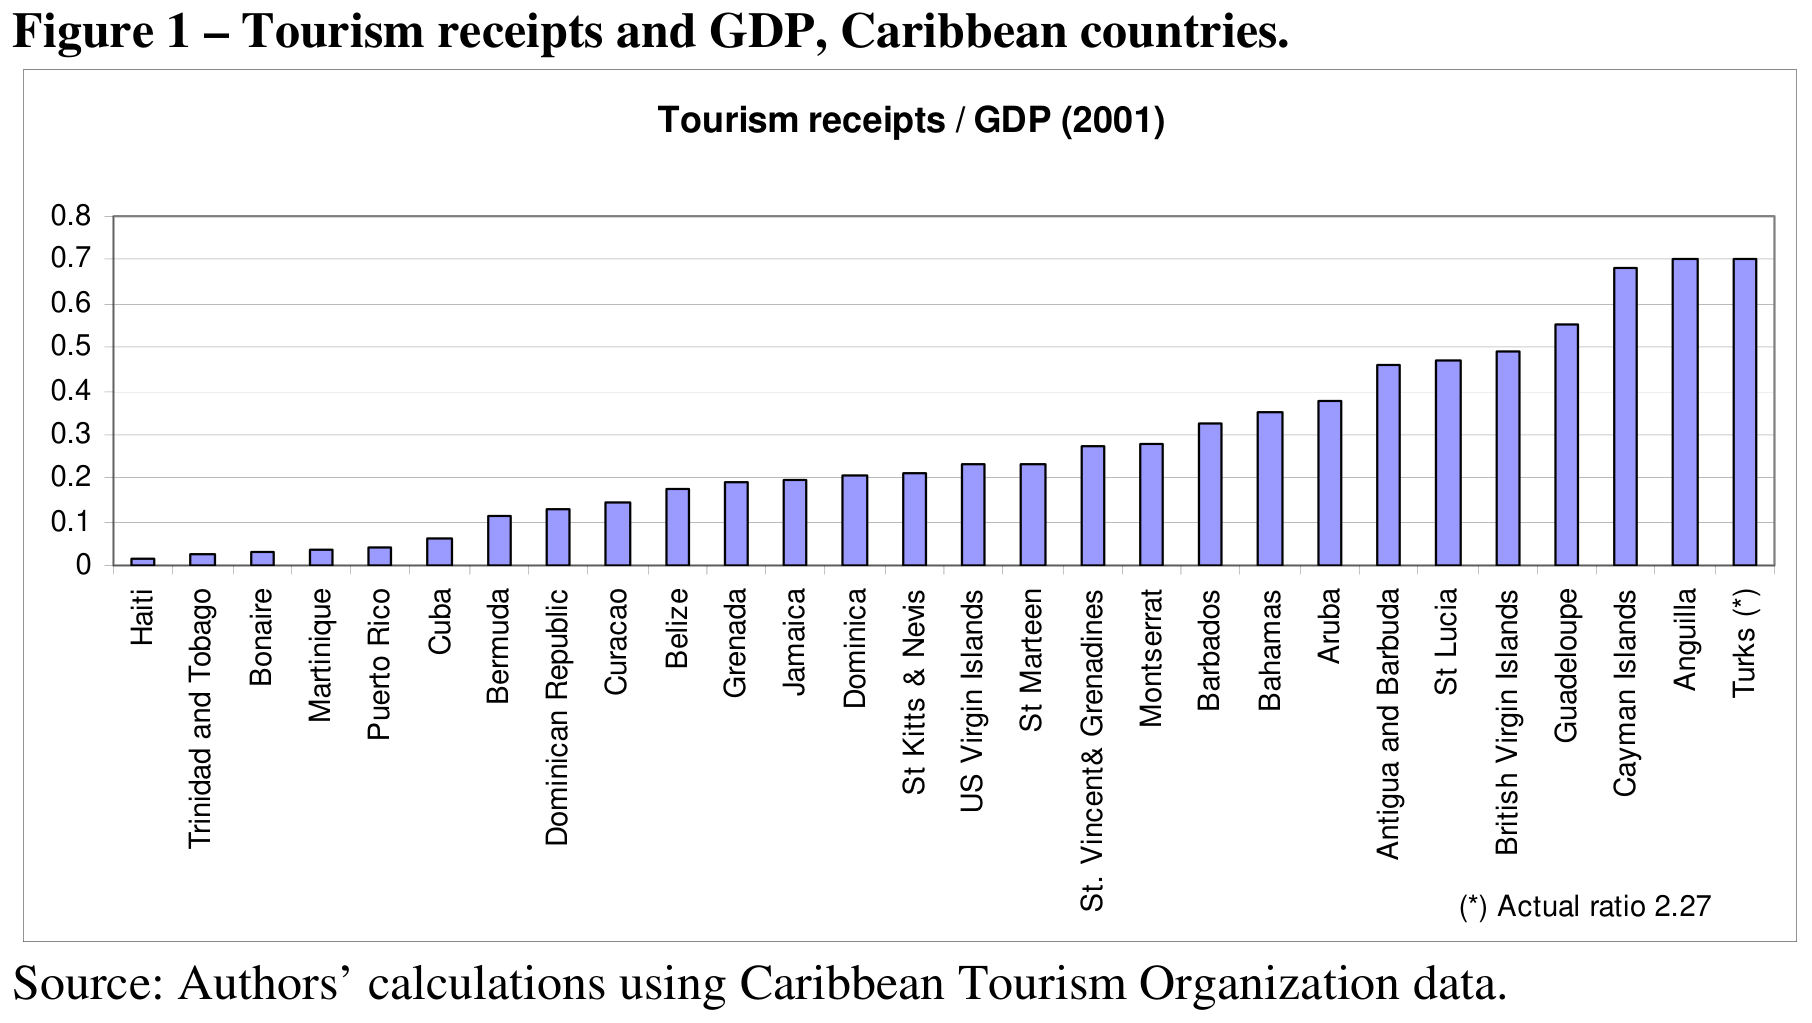

source,artifact_type,model,service_tier,elapsed_seconds,input_tokens,cached_input_tokens,output_tokens,cost_usd
prwp,figure,gpt-5.5,flex,38.6,"7,614","6,912","3,649",$0.0582


#### Observations

,observation_id,fit_status,metadata_concept,closest_schema_fields,evidence_source,evidence,fit_rationale
0,O1,covered,Snapshot title and document-assigned figure number,"title, internal_identifier",snapshot,"The snapshot heading reads “Figure 1 – Tourism receipts and GDP, Caribbean countries.”",The heading provides both the primary identifying title and the document-assigned identifier supported by existing fields.
1,O2,covered,Visualization type,visualization_type,snapshot,The snapshot displays vertical bars by country with a numeric y-axis.,The existing visualization_type field directly captures that the snapshot is a bar chart.
2,O3,covered,Primary measured variable,variable_name,snapshot,The chart title states “Tourism receipts / GDP (2001).”,The existing variable_name field captures the represented indicator or measured concept.
3,O4,covered,Ratio measurement context,"unit_of_measure, measure_type",snapshot,The represented measure is explicitly written as “Tourism receipts / GDP.”,The unit_of_measure and measure_type fields can represent that values are expressed as a ratio.
4,O5,covered,Represented time period,"time_period, temporal_granularity",snapshot,The chart title includes “(2001).”,"The year is directly represented by time_period, with annual temporal granularity supported by the year-only expression."
5,O6,covered,Geographic scope and entities,"geographic_scope, geographic_entities, geographic_granularity",snapshot,"The title says “Caribbean countries,” and the x-axis lists places such as Haiti, Barbados, Aruba, and Turks (*).","The existing geographic fields capture the Caribbean scope, named represented entities, and country-level reporting."
6,O7,covered,Categorical organization by country,"category_dimension, category_labels",snapshot,"The bars are organized along the x-axis by country or territory names such as Haiti, Jamaica, St Lucia, and Anguilla.",The existing category_dimension and category_labels fields capture the country-based grouping and its explicit labels.
7,O8,covered,Snapshot data source,data_source,snapshot,The source line states “Source: Authors’ calculations using Caribbean Tourism Organization data.”,The named Caribbean Tourism Organization data can be represented as the cited source from which the data originate.
8,O9,weak_fit,Data derivation or calculation statement,"data_source, analysis_method, interpretive_note",snapshot,The source line states “Authors’ calculations using Caribbean Tourism Organization data.”,"Existing fields can capture the named source or a specific method, but not the provenance fact that the displayed values are author-calculated from source data."
9,O10,covered,Interpretive footnote for exceptional plotted value,interpretive_note,snapshot,The snapshot includes the note “(*) Actual ratio 2.27” next to the Turks label.,The existing interpretive_note field captures explicit notes or caveats needed to interpret the figure.


#### Candidate fields

,proposed_name,definition,supporting_observation_ids,why_existing_fields_are_insufficient,operational_value,source_level
0,data_derivation_statement,"An explicit statement describing that represented values were derived, calculated, transformed, or otherwise produced from cited source data, including the responsible party when stated.",O9,"data_source captures the underlying cited data, analysis_method captures named analytical methods, and interpretive_note captures explanatory caveats, but none cleanly represents calculation provenance such as “Authors’ calculations using … data.”","Helps users distinguish directly reported source data from values computed or transformed by document authors, supporting interpretation, verification, and reuse.",snapshot
1,source_document_identifier,"A formal identifier assigned to the parent source document containing the snapshot, such as an institutional repository ID, publication number, or other persistent document identifier.",O13,"internal_identifier is defined for identifiers such as Figure 1 within the document, project_identifier is limited to projects or operations, and source_document_title does not preserve external document identifiers needed for retrieval or citation.","Supports reliable linking, deduplication, citation, and retrieval of snapshots through their parent documents.",document
2,source_document_url,A URL or web access locator for the parent source document containing the snapshot.,O14,source_document_title identifies the parent document textually but does not provide a retrievable access location.,"Enables users and systems to retrieve, verify, and cite the original document context for the extracted snapshot.",document


In [18]:
SNAPSHOT_INDEX = 0
inspect_result(results_df.iloc[SNAPSHOT_INDEX]["snapshot_file_name"])
